# Monreader Pt. 2

## Generating Speech from Written Text

This section will focus on generating speech from images of book pages or written works provided. Initially, it will focus on selecting a random saved image, reading form that image, and providing a brief description of that image so that the viewer can understand where it is from and the quoted text. The next cell is focused on providing the viewer the image that is being read and interpreted.

In [1]:
import anthropic
import base64
import random
import os
from pathlib import Path
from dotenv import load_dotenv
from sympy import false

load_dotenv()

API_KEY = os.getenv("MonReader_API_KEY")
IMAGE_DIR = os.getenv("Monreader_IMAGE_DIR")

SYSTEM_PROMPT = (
    "You are viewing an image that has been provided. Extract any noticeable text from the image."
    "If the text is from a page or document, extract the full text and return it in the text response"
)

IMAGE_DIR = r"C:\Users\crozi\images\Text-to-Speech"

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".webp"}

MEDIA_TYPES = {
    ".jpg":  "image/jpeg",
    ".jpeg": "image/jpeg",
    ".png":  "image/png",
    ".gif":  "image/gif",
    ".webp": "image/webp",
}

def describe_random_image():
    """Pick a random image from IMAGE_DIR and print its name and a description."""

    folder = Path(IMAGE_DIR)
    images = [f for f in folder.iterdir() if f.suffix.lower() in SUPPORTED_EXTENSIONS]

    if not images:
        print(f"No images found in: {IMAGE_DIR}")
        return

    chosen = random.choice(images)
    media_type = MEDIA_TYPES[chosen.suffix.lower()]

    with open(chosen, "rb") as f:
        image_data = base64.standard_b64encode(f.read()).decode("utf-8")

    client = anthropic.Anthropic(api_key=API_KEY)

    message = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1000,
        system=SYSTEM_PROMPT,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": image_data,
                        },
                    },
                    {"type": "text", "text": "Describe this image."}
                ],
            }
        ],
    )

    description = message.content[0].text

    print(f"Image:       {chosen.name}")
    print(f"Description: {description}")
    return chosen, description

chosen, description = describe_random_image()

Image:       il_570xN.1642296937_p8c5.jpg
Description: # F. Scott Fitzgerald Quote Print

This is a typographic print featuring the famous closing passage from **The Great Gatsby** by F. Scott Fitzgerald.

## Text Content:

**F. SCOTT FITZGERALD**

*"And as I sat there brooding on the old, unknown world, I thought of Gatsby's wonder when he first picked out the green light at the end of Daisy's dock. He had come a long way to this blue lawn, and his dream must have seemed so close that he could hardly fail to grasp it. He did not know that it was already behind him, somewhere back in that vast obscurity beyond the city, where the dark fields of the republic rolled on under the night.*

*Gatsby believed in the green light, the orgastic future that year by year recedes before us. It eluded us then, but that's no matter—to-morrow we will run faster, stretch out our arms farther. . . . And one fine morning—*

*So we beat on, boats against the current, borne back ceaselessly into the past."

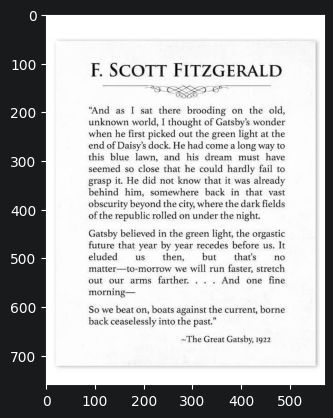

In [2]:
import matplotlib as plt

plt.pyplot.imshow(plt.image.imread(chosen))

## HuggingFace Audio

The following will use the random image provided in the previous cell and generate audio from it using transformers and HuggingFace. Since HuggingFace is being used, a token was created for use and stored in a separate .env file. Several features were included with the text-to-speech after some initial testing. These include keeping the voice consistent throughout the speech generation rather than having a new speaker begin each sentence, having brief pauses depending on the punctuation used, and reviewing the chunks to try and enunciate each better.

In [3]:
import re
import os
import torch
import numpy as np
import soundfile as sf
from scipy import signal
from transformers import CsmForConditionalGeneration, AutoProcessor
from huggingface_hub import login
from dotenv import load_dotenv
from pathlib import Path

load_dotenv()

HF_TOKEN = os.environ.get("Monreader_HF_Token")
login(token=HF_TOKEN)

print("Loading CSM model...")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained("sesame/csm-1b")
model = CsmForConditionalGeneration.from_pretrained("sesame/csm-1b", device_map=DEVICE)
print(f"CSM ready on {DEVICE}.")


def clean_text(text: str) -> str:
    """Strip out formatting artifacts from Claude's image extraction."""
    lines = text.splitlines()
    cleaned_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.lower().startswith("description:"):
            continue
        if line.lower().startswith("image:"):
            continue
        cleaned_lines.append(line)

    text = " ".join(cleaned_lines)

    # Strip bullet/symbol runs (asterisks, dashes, em dashes)
    text = re.sub(r'[\*\—\-]+\s+', ' ', text)

    # Strip markdown bold/italic markers
    text = re.sub(r'\*{1,2}(.*?)\*{1,2}', r'\1', text)

    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text)

    # Strip non-ASCII except em dash
    text = re.sub(r'[^\x00-\x7F—]+', '', text)

    return text.strip()


def make_silence(duration_ms: int, sample_rate: int = 24000) -> np.ndarray:
    """Generate silence for a given duration in milliseconds."""
    num_samples = int(sample_rate * duration_ms / 1000)
    return np.zeros(num_samples, dtype=np.float32)


def enhance_audio(audio_np: np.ndarray, sample_rate: int = 24000) -> np.ndarray:
    """Remove muffle and boost voice clarity."""
    # High-pass filter to remove low-frequency rumble
    sos = signal.butter(4, 80, 'hp', fs=sample_rate, output='sos')
    audio_np = signal.sosfilt(sos, audio_np)

    # Presence boost in the 2k-5k Hz range for voice clarity
    sos_presence = signal.butter(2, [2000, 5000], 'bp', fs=sample_rate, output='sos')
    presence = signal.sosfilt(sos_presence, audio_np)
    audio_np = audio_np + 0.3 * presence

    # Normalize
    max_val = np.max(np.abs(audio_np))
    if max_val > 0:
        audio_np = audio_np / max_val * 0.95

    return audio_np.astype(np.float32)


def build_voice_context(processor, model, device):
    """Generate a warm-up phrase to anchor a consistent, pleasant voice."""
    warmup_text = "Welcome. I will be reading this passage for you today."
    conversation = [
        {"role": "0", "content": [{"type": "text", "text": warmup_text}]}
    ]
    inputs = processor.apply_chat_template(
        conversation, tokenize=True, return_dict=True
    ).to(device)

    audio = model.generate(**inputs, output_audio=True, max_new_tokens=1024)
    audio_np = audio[0].to(torch.float32).cpu().numpy()

    return [{
        "role": "0",
        "content": [
            {"type": "text", "text": warmup_text},
            {"type": "audio", "path": audio_np},
        ]
    }]


def speak_text(text: str, output_path: str = "output.wav"):
    """Convert extracted text to speech with pauses, consistent voice, and audio enhancement."""
    text = clean_text(text)

    # Replace ellipses with em dash as a longer-pause marker
    text = re.sub(r'\.{2,}', ' — ', text)

    # Ensure text ends with a sentence terminator
    if not text.endswith('.') and not text.endswith('—'):
        text += '.'

    print(f"Cleaned text:\n{text}\n")

    # Split on sentence-ending punctuation, keeping the delimiter
    segments = re.split(r'([\.—])', text)

    chunks_with_pauses = []
    i = 0
    while i < len(segments):
        segment = segments[i].strip()
        if not segment:
            i += 1
            continue
        pause_ms = 0
        if i + 1 < len(segments):
            punct = segments[i + 1]
            if punct == '.':
                pause_ms = 400
            elif punct == '—':
                pause_ms = 600
            i += 2
        else:
            i += 1
        if len(segment) > 1:
            chunks_with_pauses.append((segment, pause_ms))

    audio_chunks = []
    context = build_voice_context(processor, model, DEVICE)
    MAX_CONTEXT = 1

    for idx, (segment, pause_ms) in enumerate(chunks_with_pauses):
        print(f"Generating {idx+1}/{len(chunks_with_pauses)}: {segment[:60]}...")

        conversation = context + [
            {"role": "0", "content": [{"type": "text", "text": segment + "."}]}
        ]
        inputs = processor.apply_chat_template(
            conversation, tokenize=True, return_dict=True
        ).to(DEVICE)

        audio = model.generate(**inputs, output_audio=True, max_new_tokens=1024)
        audio_np = audio[0].to(torch.float32).cpu().numpy()
        audio_chunks.append(audio_np)

        if pause_ms > 0:
            audio_chunks.append(make_silence(pause_ms))

        context.append({
            "role": "0",
            "content": [
                {"type": "text", "text": segment + "."},
                {"type": "audio", "path": audio_np},
            ]
        })
        if len(context) > MAX_CONTEXT:
            context.pop(0)

    if audio_chunks:
        full_audio = np.concatenate(audio_chunks)
        full_audio = enhance_audio(full_audio)
        sf.write(output_path, full_audio, 24000)
        print(f"Audio saved to: {output_path}")


if chosen and description:
    audio_file = chosen.stem + "_HF_audio.wav"
    speak_text(description, output_path=audio_file)

C:\Users\crozi\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'CsmForConditionalGeneration' from 'transformers' (C:\Users\crozi\PyCharmMiscProject\.venv\Lib\site-packages\transformers\__init__.py)

# VibeVoice

After creating an output with HuggingFace, it was decided to create another output using another text-to-speech using VibeVoice for comparison. Unlike the HuggingFace generated speech above, VibeVoice doesn't require a token to be used in order to help generate the speech. Much of what was structured for Sesame is the same, but Vibevoice requires some minor changes in order to process. Once the changes are made, there are some noticeable differences. Mainly, the voice does come across as more natural with less skipping, but it often has trouble in certain sections where pauses occur. This is an issue that while previously encountered by Sesame, was often much shorter and more together. The overall voice quality and results though are well done and sound almost like a human voice reading text.

In [5]:
import re, os, sys, copy, torch
import numpy as np
import soundfile as sf
from scipy import signal
from huggingface_hub import snapshot_download
from dotenv import load_dotenv
from transformers.cache_utils import DynamicCache
from transformers.modeling_outputs import BaseModelOutputWithPast

load_dotenv()

for key in list(sys.modules.keys()):
    if 'vibevoice' in key:
        del sys.modules[key]

if 'model' not in dir():
    from vibevoice.modular.modeling_vibevoice_streaming_inference import VibeVoiceStreamingForConditionalGenerationInference
    from vibevoice.processor.vibevoice_streaming_processor import VibeVoiceStreamingProcessor

    print("Downloading VibeVoice Realtime model...")
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    MODEL_DIR = snapshot_download(
        "microsoft/VibeVoice-Realtime-0.5B",
        local_dir=os.path.join(os.path.expanduser("~"), "models", "VibeVoice-Realtime-0.5B"),
    )

    processor = VibeVoiceStreamingProcessor.from_pretrained(MODEL_DIR)
    model = VibeVoiceStreamingForConditionalGenerationInference.from_pretrained(
        MODEL_DIR,
        torch_dtype=torch.float32,
        attn_implementation="sdpa",
        device_map="cpu" if DEVICE == "cpu" else None,
    )
    if DEVICE != "cpu":
        model.to(DEVICE)
    model.eval()
    model.set_ddpm_inference_steps(num_steps=5)
    print(f"VibeVoice Realtime ready on {DEVICE}.")
else:
    print("Model already loaded, skipping.")

Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 3186.76it/s]
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'Qwen2Tokenizer'. 
The class this function is called from is 'VibeVoiceTextTokenizerFast'.
Some weights of VibeVoiceStreamingForConditionalGenerationInference were not initialized from the model checkpoint at C:\Users\crozi\models\VibeVoice-Realtime-0.5B and are newly initialized: ['model.acoustic_tokenizer.encoder.downsample_layers.0.0.conv.conv.bias', 'model.acoustic_tokenizer.encoder.downsample_layers.0.0.conv.conv.weight', 'model.acoustic_tokenizer.encoder.downsample_layers.1.0.conv.conv.bias', 'model.acoustic_tokenizer.encoder.downsample_layers.1.0.conv.conv.weight', 'model.acoustic_tokenizer.encoder.downsample_layers.2.0.conv.conv.bias', 'model.acoustic_tokenizer.encoder.downsample_layers.2.0.conv.conv.weight

VibeVoice Realtime ready on cpu.


In [6]:
import glob

SPEAKER_NAME = "en-breeze_woman"  # use lowercase filename without .pt

VOICES_DIR = os.path.join(os.path.expanduser("~"), "VibeVoice", "demo", "voices", "streaming_model")

# Auto-discover all .pt voice files
VOICE_FILES = {}
for pt_file in glob.glob(os.path.join(VOICES_DIR, "**", "*.pt"), recursive=True):
    name = os.path.splitext(os.path.basename(pt_file))[0].lower()
    VOICE_FILES[name] = pt_file

print(f"Available voices: {list(VOICE_FILES.keys())}")


def load_voice_sample(speaker: str):
    """Load pre-computed voice embeddings from .pt file."""
    speaker = speaker.lower()
    if speaker not in VOICE_FILES:
        raise ValueError(f"Unknown speaker '{speaker}'. Available: {list(VOICE_FILES.keys())}")
    pt_path = VOICE_FILES[speaker]
    voice = torch.load(pt_path, map_location=DEVICE, weights_only=False)
    return voice

VOICE_SAMPLE = load_voice_sample(SPEAKER_NAME)
print(f"Loaded voice '{SPEAKER_NAME}'.")


def clean_text(text: str) -> str:
    lines = text.splitlines()
    cleaned_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.lower().startswith("description:") or line.lower().startswith("image:"):
            continue
        cleaned_lines.append(line)
    text = " ".join(cleaned_lines)
    text = re.sub(r'[\*\—\-]+\s+', ' ', text)
    text = re.sub(r'\*{1,2}(.*?)\*{1,2}', r'\1', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\x00-\x7F—]+', '', text)
    return text.strip()


def make_silence(duration_ms: int, sample_rate: int = 24000) -> np.ndarray:
    return np.zeros(int(sample_rate * duration_ms / 1000), dtype=np.float32)


def trim_trailing_noise(audio_np, sample_rate=24000, threshold=0.01, pad_ms=150):
    nonsilent = np.where(np.abs(audio_np) > threshold)[0]
    if len(nonsilent) == 0:
        return audio_np
    end = nonsilent[-1] + int(sample_rate * pad_ms / 1000)
    return audio_np[:min(end, len(audio_np))]


def enhance_audio(audio_np, sample_rate=24000):
    sos = signal.butter(4, 80, 'hp', fs=sample_rate, output='sos')
    audio_np = signal.sosfilt(sos, audio_np)
    sos_presence = signal.butter(2, [2000, 5000], 'bp', fs=sample_rate, output='sos')
    audio_np = audio_np + 0.3 * signal.sosfilt(sos_presence, audio_np)
    max_val = np.max(np.abs(audio_np))
    if max_val > 0:
        audio_np = audio_np / max_val * 0.95
    return audio_np.astype(np.float32)

def generate_segment(text: str) -> np.ndarray:
    inputs = processor.process_input_with_cached_prompt(
        text=text,
        cached_prompt=VOICE_SAMPLE,
        padding=True,
        return_tensors="pt",
        return_attention_mask=True,
    )
    for k, v in inputs.items():
        if torch.is_tensor(v):
            inputs[k] = v.to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            tokenizer=processor.tokenizer,
            cfg_scale=1.5,
            verbose=False,
            all_prefilled_outputs=copy.deepcopy(VOICE_SAMPLE),
        )

    audio = output.speech_outputs[0].squeeze().to(torch.float32).cpu().numpy()
    return trim_trailing_noise(audio)

def speak_text(text: str, output_path: str = "output.wav"):
    text = clean_text(text)
    text = re.sub(r'\.{2,}', ' — ', text)
    if not text.endswith(('.', '—', '!', '?')):
        text += '.'
    print(f"Cleaned text:\n{text}\n")

    sentences = re.findall(r'[^.—!?]+[.—!?]', text)
    chunks = [(s.strip(), 600 if s.strip().endswith('—') else 400)
              for s in sentences if s.strip()]
    if not chunks:
        chunks = [(text, 0)]

    audio_chunks = []
    for idx, (segment, pause_ms) in enumerate(chunks):
        print(f"Generating {idx+1}/{len(chunks)}: {segment[:60]}...")
        audio_chunks.append(generate_segment(segment))
        if pause_ms > 0:
            audio_chunks.append(make_silence(pause_ms))

    if audio_chunks:
        full_audio = enhance_audio(np.concatenate(audio_chunks))
        sf.write(output_path, full_audio, 24000)
        print(f"Audio saved to: {output_path}")


# --- Run inference ---
if chosen and description:
    audio_file = chosen.stem + "_VV_audio.wav"
    speak_text(description, output_path=audio_file)

Available voices: ['en-breeze_woman', 'en-brutalon_man', 'en-clarion_man', 'en-clarissa_woman', 'en-gravitar_man', 'en-gravus_man', 'en-mechcorsair_man', 'en-oldenheart_man', 'en-silkvox_man', 'en-snarkling_woman', 'en-soother_woman']
Loaded voice 'en-breeze_woman'.
Cleaned text:
# F. Scott Fitzgerald Quote Print This is a typographic print featuring a famous passage from "The Great Gatsby" by F. Scott Fitzgerald. ## The Text Reads: F. SCOTT FITZGERALD "And as I sat there brooding on the old, unknown world, I thought of Gatsby's wonder when he first picked out the green light at the end of Daisy's dock. He had come a long way to this blue lawn, and his dream must have seemed so close that he could hardly fail to grasp it. He did not know that it was already behind him, somewhere back in that vast obscurity beyond the city, where the dark fields of the republic rolled on under the night. Gatsby believed in the green light, the orgastic future that year by year recedes before us. It elud

Generating 2/15: Scott Fitzgerald Quote Print This is a typographic print fea...


Generating 3/15: Scott Fitzgerald....


Generating 4/15: ## The Text Reads: F....


Generating 5/15: SCOTT FITZGERALD "And as I sat there brooding on the old, un...


...

Generating 12/15: ....


Generating 13/15: ....


Generating 14/15: And one fine morning So we beat on, boats against the curren...


Generating 15/15: " ~The Great Gatsby, 1922 This contains one of the most icon...


Audio saved to: il_570xN.1642296937_p8c5_VV_audio.wav


# Monreader Application

After successfully testing with both Sesame and VibeVoice, we can determine which is best to assemble into an application that can be used for reading text and providing a voice to it. When initially building the application, I used the creation from Sesame because it had better clarity despite having slight muffling occasionally when reading long passages. I did however make some tweaks and switch to VibeVoice as this version was clearer and had a more consistent tone. I generated several blocks along with some basic features such as buttons to confirm selections. This version still requires tokens in order to run, but it's a huge step towards developing speech from written text.

In [9]:
"""
Monreader — Book Page to Speech  (VibeVoice-Realtime-0.5B edition)
Scans book page images with Claude, then reads them aloud with VibeVoice.

PREREQUISITE — one-time package patch:
  Edit  .venv/Lib/site-packages/vibevoice/modular/modeling_vibevoice_inference.py
  Find line ~222:
    acoustic_features, speech_embeds = self._process_speech_inputs(speech_tensors.to(self.dtype), speech_masks)
  Replace with:
    acoustic_features, speech_embeds = self._process_speech_inputs(speech_tensors.to(self.dtype), speech_masks, speech_type=getattr(self, '_speech_input_type', 'audio'))

  Also in  .venv/Lib/site-packages/vibevoice/modular/modular_vibevoice_tokenizer.py
  Find lines ~1188-1189 (two AutoModel.register calls) and add exist_ok=True to each:
    AutoModel.register(..., exist_ok=True)
"""

import re
import os
import queue
import base64
import threading
from pathlib import Path

import anthropic
import numpy as np
import soundfile as sf
import torch
from dotenv import load_dotenv
from scipy import signal

# VibeVoice imports
from vibevoice.modular.modeling_vibevoice_streaming_inference import (
    VibeVoiceStreamingForConditionalGenerationInference,
)
from vibevoice.processor.vibevoice_streaming_processor import VibeVoiceStreamingProcessor

import tkinter as tk
from tkinter import filedialog, messagebox, scrolledtext, ttk

# ---------------------------------------------------------------------------
# Load .env from project root
# ---------------------------------------------------------------------------
load_dotenv()

SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".gif", ".webp"}
MEDIA_TYPES = {
    ".jpg":  "image/jpeg",
    ".jpeg": "image/jpeg",
    ".png":  "image/png",
    ".gif":  "image/gif",
    ".webp": "image/webp",
}

MODEL_ID   = "microsoft/VibeVoice-Realtime-0.5B"
VOICE_PATH = Path(r"C:\Users\crozi\VibeVoice\demo\voices")  # folder holding .pt files

PAGE_EXTRACT_PROMPT = (
    "Extract and transcribe all readable text from this book page. "
    "Return only the raw text, preserving paragraph breaks with a blank line. "
    "Do not include page numbers, headers, footers, or any commentary."
)


# ---------------------------------------------------------------------------
# Text helpers
# ---------------------------------------------------------------------------

def clean_text(text: str) -> str:
    lines = text.splitlines()
    cleaned = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.lower().startswith(("description:", "image:")):
            continue
        cleaned.append(line)
    text = " ".join(cleaned)
    text = re.sub(r'[\*\u2022\-\u2013\u2014]+\s+', ' ', text)
    text = re.sub(r'\*{1,2}(.*?)\*{1,2}', r'\1', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\x00-\x7F\u2026]+', '', text)
    return text.strip()


def make_silence(duration_ms: int, sample_rate: int = 24000) -> np.ndarray:
    return np.zeros(int(sample_rate * duration_ms / 1000), dtype=np.float32)


def trim_trailing_noise(audio: np.ndarray, threshold: float = 0.01) -> np.ndarray:
    """Remove near-silence tail that sometimes causes a muffled end artifact."""
    abs_audio = np.abs(audio)
    mask = abs_audio > threshold
    if not mask.any():
        return audio
    last = int(np.where(mask)[0][-1])
    return audio[: last + 1]


def enhance_audio(audio_np: np.ndarray, sample_rate: int = 24000) -> np.ndarray:
    sos = signal.butter(4, 80, 'hp', fs=sample_rate, output='sos')
    audio_np = signal.sosfilt(sos, audio_np)
    sos_p = signal.butter(2, [2000, 5000], 'bp', fs=sample_rate, output='sos')
    presence = signal.sosfilt(sos_p, audio_np)
    audio_np = audio_np + 0.3 * presence
    mx = np.max(np.abs(audio_np))
    if mx > 0:
        audio_np = audio_np / mx * 0.95
    return audio_np.astype(np.float32)


# ---------------------------------------------------------------------------
# Claude text extraction
# ---------------------------------------------------------------------------

def extract_text_from_image(image_path: Path, anthropic_key: str) -> str:
    ext = image_path.suffix.lower()
    media_type = MEDIA_TYPES.get(ext, "image/jpeg")
    with open(image_path, "rb") as f:
        image_data = base64.standard_b64encode(f.read()).decode("utf-8")

    client = anthropic.Anthropic(api_key=anthropic_key)
    msg = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2000,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {"type": "base64", "media_type": media_type, "data": image_data},
                },
                {"type": "text", "text": PAGE_EXTRACT_PROMPT},
            ]
        }]
    )
    return msg.content[0].text


# ---------------------------------------------------------------------------
# VibeVoice inference
# ---------------------------------------------------------------------------

def load_voice_sample(pt_path: Path) -> dict:
    """Load a pre-computed .pt voice preset (BaseModelOutputWithPast tensor dict)."""
    return torch.load(str(pt_path), weights_only=False)


def generate_segment(
    text: str,
    processor: VibeVoiceStreamingProcessor,
    model: VibeVoiceStreamingForConditionalGenerationInference,
    voice_sample: dict,
    device: str,
) -> np.ndarray:
    """Synthesise one sentence-length segment using the VibeVoice PT voice latents."""
    text_inputs = processor.tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        return_attention_mask=True,
    )
    for k, v in text_inputs.items():
        if torch.is_tensor(v):
            text_inputs[k] = v.to(device)

    # voice_sample['lm']['last_hidden_state'] → [1, T, 896] pre-computed latents
    speech_tensors = voice_sample['lm']['last_hidden_state'].to(device)
    T = speech_tensors.shape[1]
    speech_masks = torch.ones(1, T, dtype=torch.bool, device=device)

    seq_len = text_inputs['input_ids'].shape[1]
    speech_input_mask = torch.zeros(1, seq_len, dtype=torch.bool, device=device)
    speech_input_mask[0, :min(T, seq_len)] = True

    # Tell the patched _process_speech_inputs to use the "pt" path
    model._speech_input_type = "pt"
    try:
        with torch.no_grad():
            output = model.generate(
                input_ids=text_inputs["input_ids"],
                attention_mask=text_inputs["attention_mask"],
                tokenizer=processor.tokenizer,
                speech_tensors=speech_tensors,
                speech_masks=speech_masks,
                speech_input_mask=speech_input_mask,
                cfg_scale=1.5,
                return_speech=True,
                verbose=False,
            )
    finally:
        model._speech_input_type = "audio"  # always reset

    audio = output.speech_outputs[0].squeeze().to(torch.float32).cpu().numpy()
    return trim_trailing_noise(audio)


def speak_text(
    text: str,
    output_path: str,
    processor: VibeVoiceStreamingProcessor,
    model: VibeVoiceStreamingForConditionalGenerationInference,
    voice_sample: dict,
    device: str,
    log_fn=print,
):
    """Convert a block of text to speech and save as a .wav file."""
    text = clean_text(text)
    text = re.sub(r'\.{2,}', '\u2026', text)
    if not text.endswith(('.', '\u2026')):
        text += '.'

    log_fn(f"  Cleaned text: {len(text)} characters")

    # Split into sentence chunks
    segments = re.split(r'([.\u2026])', text)
    chunks: list[tuple[str, int]] = []
    i = 0
    while i < len(segments):
        seg = segments[i].strip()
        if not seg:
            i += 1
            continue
        pause_ms = 0
        if i + 1 < len(segments):
            punct = segments[i + 1]
            pause_ms = 600 if punct == '\u2026' else 400
            i += 2
        else:
            i += 1
        if len(seg) > 1:
            chunks.append((seg, pause_ms))

    if not chunks:
        log_fn("  No speakable text found — skipping.")
        return

    audio_chunks: list[np.ndarray] = []

    for idx, (seg, pause_ms) in enumerate(chunks):
        log_fn(f"  Segment {idx+1}/{len(chunks)}: {seg[:55]}...")
        audio_np = generate_segment(seg + ".", processor, model, voice_sample, device)
        audio_chunks.append(audio_np)
        if pause_ms > 0:
            audio_chunks.append(make_silence(pause_ms))

    full_audio = np.concatenate(audio_chunks)
    full_audio = enhance_audio(full_audio)
    sf.write(output_path, full_audio, 24000)
    log_fn(f"  Saved -> {output_path}")


# ---------------------------------------------------------------------------
# GUI
# ---------------------------------------------------------------------------

class MonreaderApp:
    def __init__(self, root: tk.Tk):
        self.root = root
        self.root.title("Monreader — Book Page Reader (VibeVoice)")
        self.root.geometry("780x700")
        self.root.resizable(True, True)

        self.model = None
        self.processor = None
        self.voice_sample = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model_loaded = False
        self.log_queue: queue.Queue = queue.Queue()
        self._busy = False

        self._build_ui()
        self._poll_log()

    # ------------------------------------------------------------------
    # UI construction
    # ------------------------------------------------------------------

    def _build_ui(self):
        pad = {"padx": 10, "pady": 5}

        # --- API keys ---
        keys_frame = ttk.LabelFrame(self.root, text=" API Keys ")
        keys_frame.pack(fill="x", **pad)

        ttk.Label(keys_frame, text="Anthropic Key:").grid(
            row=0, column=0, sticky="w", padx=6, pady=3)
        self.anthropic_key_var = tk.StringVar(
            value=os.environ.get("ANTHROPIC_API_KEY", ""))
        ttk.Entry(keys_frame, textvariable=self.anthropic_key_var,
                  width=58, show="*").grid(row=0, column=1, padx=6, pady=3)

        ttk.Label(keys_frame, text="HuggingFace Token:").grid(
            row=1, column=0, sticky="w", padx=6, pady=3)
        self.hf_token_var = tk.StringVar(
            value=os.environ.get("Monreader_HF_Token", ""))
        ttk.Entry(keys_frame, textvariable=self.hf_token_var,
                  width=58, show="*").grid(row=1, column=1, padx=6, pady=3)

        # --- Model ---
        model_frame = ttk.LabelFrame(self.root, text=" Model ")
        model_frame.pack(fill="x", **pad)

        self.load_btn = ttk.Button(
            model_frame, text="Load VibeVoice Model", command=self._load_model)
        self.load_btn.pack(side="left", padx=8, pady=6)

        self.model_status_var = tk.StringVar(
            value=f"Not loaded  |  Device: {self.device}")
        ttk.Label(model_frame, textvariable=self.model_status_var,
                  foreground="gray").pack(side="left", padx=8)

        # --- Voice preset ---
        voice_frame = ttk.LabelFrame(self.root, text=" Voice Preset (.pt file) ")
        voice_frame.pack(fill="x", **pad)

        ttk.Label(voice_frame, text="Voice file:").grid(
            row=0, column=0, sticky="w", padx=6, pady=3)
        self.voice_path_var = tk.StringVar()
        # Auto-populate if the default voice folder exists
        default_voice = VOICE_PATH / "Alice.pt"
        if default_voice.exists():
            self.voice_path_var.set(str(default_voice))
        ttk.Entry(voice_frame, textvariable=self.voice_path_var,
                  width=52).grid(row=0, column=1, padx=6, pady=3)
        ttk.Button(voice_frame, text="Browse…",
                   command=self._browse_voice).grid(row=0, column=2, padx=4)

        # --- Tabs ---
        nb = ttk.Notebook(self.root)
        nb.pack(fill="x", **pad)

        single_tab = ttk.Frame(nb, padding=8)
        nb.add(single_tab, text="  Single Image  ")

        ttk.Label(single_tab, text="Image File:").grid(
            row=0, column=0, sticky="w", pady=3)
        self.single_path_var = tk.StringVar()
        ttk.Entry(single_tab, textvariable=self.single_path_var,
                  width=52).grid(row=0, column=1, padx=6, pady=3)
        ttk.Button(single_tab, text="Browse…",
                   command=self._browse_single_image).grid(row=0, column=2, padx=4)

        ttk.Label(single_tab, text="Output Folder:").grid(
            row=1, column=0, sticky="w", pady=3)
        self.single_out_var = tk.StringVar()
        ttk.Entry(single_tab, textvariable=self.single_out_var,
                  width=52).grid(row=1, column=1, padx=6, pady=3)
        ttk.Button(single_tab, text="Browse…",
                   command=lambda: self._browse_folder(self.single_out_var)
                   ).grid(row=1, column=2, padx=4)

        self.single_btn = ttk.Button(
            single_tab, text="Generate Audio",
            command=self._run_single, state="disabled")
        self.single_btn.grid(row=2, column=1, pady=8, sticky="w")

        folder_tab = ttk.Frame(nb, padding=8)
        nb.add(folder_tab, text="  Folder Scan  ")

        ttk.Label(folder_tab, text="Image Folder:").grid(
            row=0, column=0, sticky="w", pady=3)
        self.folder_path_var = tk.StringVar()
        ttk.Entry(folder_tab, textvariable=self.folder_path_var,
                  width=52).grid(row=0, column=1, padx=6, pady=3)
        ttk.Button(folder_tab, text="Browse…",
                   command=lambda: self._browse_folder(self.folder_path_var)
                   ).grid(row=0, column=2, padx=4)

        ttk.Label(folder_tab, text="Output Folder:").grid(
            row=1, column=0, sticky="w", pady=3)
        self.folder_out_var = tk.StringVar()
        ttk.Entry(folder_tab, textvariable=self.folder_out_var,
                  width=52).grid(row=1, column=1, padx=6, pady=3)
        ttk.Button(folder_tab, text="Browse…",
                   command=lambda: self._browse_folder(self.folder_out_var)
                   ).grid(row=1, column=2, padx=4)

        self.folder_btn = ttk.Button(
            folder_tab, text="Generate All",
            command=self._run_folder, state="disabled")
        self.folder_btn.grid(row=2, column=1, pady=8, sticky="w")

        # --- Progress + Log ---
        self.progress = ttk.Progressbar(self.root, mode="indeterminate")
        self.progress.pack(fill="x", padx=10, pady=(0, 2))

        log_frame = ttk.LabelFrame(self.root, text=" Log ")
        log_frame.pack(fill="both", expand=True, **pad)

        self.log_text = scrolledtext.ScrolledText(
            log_frame, height=14, wrap="word", state="normal",
            font=("Courier New", 9))
        self.log_text.pack(fill="both", expand=True, padx=4, pady=4)

        ttk.Button(log_frame, text="Clear Log",
                   command=self._clear_log).pack(anchor="e", padx=4, pady=(0, 4))

    # ------------------------------------------------------------------
    # Logging
    # ------------------------------------------------------------------

    def log(self, msg: str):
        self.log_queue.put(msg)

    def _poll_log(self):
        try:
            while True:
                msg = self.log_queue.get_nowait()
                self.log_text.insert(tk.END, msg + "\n")
                self.log_text.see(tk.END)
        except queue.Empty:
            pass
        self.root.after(100, self._poll_log)

    def _clear_log(self):
        self.log_text.delete("1.0", tk.END)

    # ------------------------------------------------------------------
    # Busy state
    # ------------------------------------------------------------------

    def _set_busy(self, busy: bool):
        self._busy = busy
        state = "disabled" if busy else "normal"
        self.load_btn.config(state=state)
        if self.model_loaded:
            self.single_btn.config(state=state)
            self.folder_btn.config(state=state)
        if busy:
            self.progress.start(10)
        else:
            self.progress.stop()

    # ------------------------------------------------------------------
    # File dialogs
    # ------------------------------------------------------------------

    def _browse_single_image(self):
        path = filedialog.askopenfilename(
            title="Select a book page image",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.gif *.webp"),
                       ("All files", "*.*")])
        if path:
            self.single_path_var.set(path)
            if not self.single_out_var.get():
                self.single_out_var.set(str(Path(path).parent))

    def _browse_folder(self, var: tk.StringVar):
        path = filedialog.askdirectory(title="Select a folder")
        if path:
            var.set(path)

    def _browse_voice(self):
        path = filedialog.askopenfilename(
            title="Select a VibeVoice .pt preset",
            filetypes=[("PyTorch voice preset", "*.pt"), ("All files", "*.*")],
            initialdir=str(VOICE_PATH) if VOICE_PATH.exists() else None,
        )
        if path:
            self.voice_path_var.set(path)

    # ------------------------------------------------------------------
    # Key validation
    # ------------------------------------------------------------------

    def _validate_keys(self) -> bool:
        if not self.anthropic_key_var.get().strip():
            messagebox.showerror("Missing Key", "Please enter your Anthropic API key.")
            return False
        return True

    # ------------------------------------------------------------------
    # Model loading
    # ------------------------------------------------------------------

    def _load_model(self):
        if not self._validate_keys():
            return
        self._set_busy(True)
        self.model_status_var.set("Loading… (first run may download model weights)")
        threading.Thread(target=self._load_model_worker, daemon=True).start()

    def _load_model_worker(self):
        try:
            from huggingface_hub import login
            hf_token = self.hf_token_var.get().strip()
            if hf_token:
                self.log("Logging in to HuggingFace…")
                login(token=hf_token)

            self.log("Loading VibeVoice processor…")
            self.processor = VibeVoiceStreamingProcessor.from_pretrained(MODEL_ID)

            self.log("Loading VibeVoice model weights…")
            self.model = VibeVoiceStreamingForConditionalGenerationInference.from_pretrained(
                MODEL_ID, torch_dtype=torch.float32
            ).to(self.device)
            self.model.eval()

            # Load the voice preset
            voice_pt = self.voice_path_var.get().strip()
            if voice_pt and Path(voice_pt).exists():
                self.log(f"Loading voice preset: {Path(voice_pt).name}")
                self.voice_sample = load_voice_sample(Path(voice_pt))
            else:
                self.log("WARNING: No valid voice .pt file selected — you must set one before generating audio.")

            self.model_loaded = True
            self.log(f"VibeVoice ready on {self.device}.")
            self.root.after(0, self._on_model_loaded)

        except Exception as e:
            self.log(f"ERROR loading model: {e}")
            self.root.after(0, lambda: self.model_status_var.set("Load failed — see log"))
            self.root.after(0, lambda: self._set_busy(False))

    def _on_model_loaded(self):
        self.model_status_var.set(f"VibeVoice loaded \u2713  |  Device: {self.device}")
        self.single_btn.config(state="normal")
        self.folder_btn.config(state="normal")
        self._set_busy(False)

    # ------------------------------------------------------------------
    # Run single / folder
    # ------------------------------------------------------------------

    def _run_single(self):
        img_path = self.single_path_var.get().strip()
        out_dir  = self.single_out_var.get().strip()
        if not img_path:
            messagebox.showerror("No image", "Please select an image file.")
            return
        if not out_dir:
            messagebox.showerror("No output folder", "Please choose an output folder.")
            return
        if self.voice_sample is None:
            messagebox.showerror("No voice", "Please select a .pt voice preset and reload the model.")
            return
        p = Path(img_path)
        if p.suffix.lower() not in SUPPORTED_EXT:
            messagebox.showerror("Unsupported file",
                                 f"'{p.suffix}' is not a supported image type.")
            return
        self._set_busy(True)
        threading.Thread(target=self._process_image_worker,
                         args=(p, Path(out_dir)), daemon=True).start()

    def _run_folder(self):
        img_dir = self.folder_path_var.get().strip()
        out_dir  = self.folder_out_var.get().strip()
        if not img_dir:
            messagebox.showerror("No folder", "Please select an image folder.")
            return
        if not out_dir:
            messagebox.showerror("No output folder", "Please choose an output folder.")
            return
        if self.voice_sample is None:
            messagebox.showerror("No voice", "Please select a .pt voice preset and reload the model.")
            return
        images = sorted(
            f for f in Path(img_dir).iterdir()
            if f.is_file() and f.suffix.lower() in SUPPORTED_EXT
        )
        if not images:
            messagebox.showinfo("Empty folder", "No supported images found in that folder.")
            return
        self.log(f"Found {len(images)} image(s) in {img_dir}")
        self._set_busy(True)
        threading.Thread(target=self._process_folder_worker,
                         args=(images, Path(out_dir)), daemon=True).start()

    # ------------------------------------------------------------------
    # Workers
    # ------------------------------------------------------------------

    def _process_image_worker(self, img_path: Path, out_dir: Path):
        try:
            self.log(f"\n-- {img_path.name} --")
            self.log("Extracting text with Claude…")
            text = extract_text_from_image(
                img_path, self.anthropic_key_var.get().strip())
            self.log(f"Extracted {len(text)} characters.")

            out_dir.mkdir(parents=True, exist_ok=True)
            out_wav = str(out_dir / (img_path.stem + "_audio.wav"))

            self.log("Generating speech…")
            speak_text(text, out_wav, self.processor, self.model,
                       self.voice_sample, self.device, self.log)
            self.log("Done!")
        except Exception as e:
            self.log(f"ERROR: {e}")
        finally:
            self.root.after(0, lambda: self._set_busy(False))

    def _process_folder_worker(self, images: list, out_dir: Path):
        out_dir.mkdir(parents=True, exist_ok=True)
        for i, img_path in enumerate(images):
            self.log(f"\n-- [{i+1}/{len(images)}] {img_path.name} --")
            try:
                self.log("Extracting text with Claude…")
                text = extract_text_from_image(
                    img_path, self.anthropic_key_var.get().strip())
                self.log(f"Extracted {len(text)} characters.")
                out_wav = str(out_dir / (img_path.stem + "_audio.wav"))
                self.log("Generating speech…")
                speak_text(text, out_wav, self.processor, self.model,
                           self.voice_sample, self.device, self.log)
                self.log("Done!")
            except Exception as e:
                self.log(f"ERROR on {img_path.name}: {e} — skipping.")
        self.log("\n-- All images processed. --")
        self.root.after(0, lambda: self._set_busy(False))


# ---------------------------------------------------------------------------

if __name__ == "__main__":
    root = tk.Tk()
    app = MonreaderApp(root)
    root.mainloop()

# Conclusion

This project was quite challenging to me, but I feel that this is the one that gave me the most progress in terms of understanding modern AI and Data Science. I had to initially be able to develop a method to detect when pages were being flipped in a book or in a stack of papers. Being able to accurately detect it with the training images was vital for the testing group and if I decided to deploy this as an additional feature in the final application. Upon detecting pages being flipped, the next major step was finding a way to interpret written text and do so with a degree of accuracy.

Upon completion, I now had to find an appropriate way to convert the interpreted text into speech. I was able to build two separate instances using Sesame and Vibevoice to show the capabilities of both and how it is done. Once that was done, I created an application that showed off the full capabilities of transforming written works into audio. The original goal fo the project was to find a way to generate audio of books for blink people who may not have had access to the written work through other means. I feel that by accomplishing each step within the project, I was able to meet that goal. There are still many areas to fine tune in the future, I still want to find a better way to prevent audio issues regarding certain punctuation or changes in the passages, but I feel that this application can still be used for the purpose that was the original goal.